# Problems
In this notebook, let us consider the complex Ginzburg-Landau equation (CGLE) for a variable $u(x,t)$ on a finite interval $x\in[0,300]$ with homogeneous Dirichlet boundary conditions:

$\partial_t u = u + (1+ib)\partial_{xx} u - (1+ic)|u|^2 u$\
$u_{x=0}=u_{x=300}=0$

with $b = 0.5$ and $c = -1.76$.

The complex Ginzburg-Landau equation is a nonlinear partial differential equation that describes the behavior of a complex-valued field in a system. It is a fundamental equation in the study of nonlinear dynamics and has been used to model a wide range of phenomena in physics, including superconductivity, superfluidity, and Bose-Einstein condensation.

Initial state is determined by following equation:

$u_{t=0} = 0.001 sin(5\pi\frac{x}{300})$

In [5]:
# add libraries
import numpy as np
import matplotlib.pyplot as plt
import dedalus.public as d3
from dedalus.extras.plot_tools import plot_bot_2d
figkw = {'figsize':(6,4), 'dpi':100}

In [ ]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

First, we provide basis for solver

In [6]:
# Bases
xcoord = d3.Coordinate('x')
dist = d3.Distributor(xcoord, dtype=np.complex128)
xbasis = d3.Chebyshev(xcoord, 1024, bounds=(0, 300), dealias=2)

## Problem formulations
Dedalus standardizes the formulation of all initial value problems by taking systems of symbolically specified equations boundary conditions and manipulating them into the following generic form:

$M\cdot \partial _t X + L \cdot X = F(X, t)$

where $M$ and $L$ are matrices of linear differential operators, $X$ is a state vector of the unknown fields, $F$ is a vector of general nonlinear expressions. This problem type is represented by the 'IVP' attribute.

## Problem initialization
To solver this problem, current Dedalus version requires adding tau terms as unknowns to the problem to enforce boundary conditions. Because this problem has two endpoint boundary conditions, so it requires two constant tau terms.

In [4]:
# Fields
u = dist.Field(name='u', bases=xbasis)
tau1 = dist.Field(name='tau1')
tau2 = dist.Field(name='tau2')

After instantiating fields, we must provide problem type for solver. A list of field variables is provided by using a dictionary via 'namespace' argument and using 'local()' to make all script-level definitions available inside the problem

In [7]:
# Problem
problem = d3.IVP([u, tau1, tau2], namespace=locals())

## Substitutions
This notebook only include substitutions representing aliases to operators computed from problem variables. Pls read 'Substitutions' section in [https://dedalus-project.readthedocs.io/en/latest/notebooks/dedalus_tutorial_3.html] to learn about using non-variable objects inside the problems, including other fields as forcing or non-constant coefficients (NCCs) of the PDEs.

In Dedalus, we can make aliases based on their objective. For example, let's consider a few common situations

- To create a 'Differentiate' operator for computing $\partial_x$

In [8]:
# Substitutions
dx = lambda A: d3.Differentiate(A, xcoord)
# where A is input
# how to use the 'dx' operator: dx(u) 
# certainly, it's shorter than using d3.Differentiate(u, xcoord)

- To create a simple substitution for computing the squared magnitube $|u|^2$ of $u$ variable:

In [9]:
magsq_u = u * np.conj(u)
# here, np.conj function is a Python function returning the complex conjugate, element-wise.
# e.g: np.conj(1+2j) = 1-2j
# so, u * np.conj(u) = |u|^2

- Or to define parameters in the PDEs, e.g. variables $b$ and $c$ in the PDEs of the CGLE problem

In [10]:
b = 0.5
c = -1.76
# these parameters can be defined in previous code as normal parameters
# these are defined there explicitly to indicate additional parameters in the PDEs

- also, this section can includes definations of tau polynomials

In [ ]:
# Tau polynomials
tau_basis = xbasis.derivative_basis(2)
p1 = dist.Field(bases=tau_basis)
p2 = dist.Field(bases=tau_basis)
p1['c'][-1] = 1
p2['c'][-2] = 2

## Building solver

- Select Timestepper for solver

In [ ]:
# Build solver
solver = problem.build_solver(d3.RK222) # the Runge-Kutta IMEX scheme for IVPs

- Setting stop criteria. For IVPs, we has three options: 

In [ ]:
# Stopping criteria
solver.stop_iteration = 500 # stop when reaching 500 iterations
solver.stop_wall_time = 500 # 500 seconds since solver instantiation
solver.stop_sim_time = 500 # stop at t=500 in simulation units
# we will select one of them to use in our solver

- Setting initial conditions based on the provided initial state $u_{t=0} = 0.001 sin(5\pi\frac{x}{300})$

In [ ]:
# Setup a sine wave
x = dist.local_grid(xbasis) # get the location of x-dimension
u['g'] = 1e-3 * np.sin(5 * np.pi * x / 300) # instantite the initial values of u at time t=0

2024-05-13 05:04:29,905 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 1.6e+01/s
Completed iteration 1000
Completed iteration 2000
Completed iteration 3000
Completed iteration 4000
Completed iteration 5000
Completed iteration 6000
Completed iteration 7000
Completed iteration 8000
Completed iteration 9000
Completed iteration 10000
2024-05-13 05:04:44,571 solvers 0/1 INFO :: Simulation stop time reached.


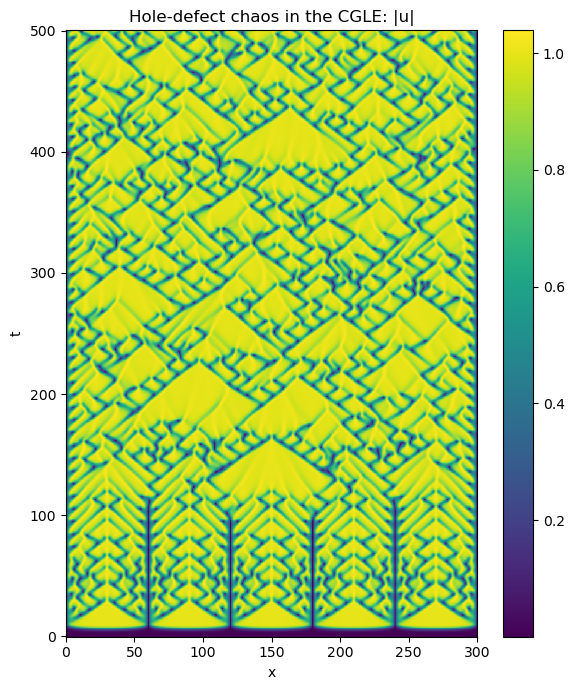

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import dedalus.public as d3
from dedalus.extras.plot_tools import plot_bot_2d
figkw = {'figsize':(6,4), 'dpi':200}

# Parameters
dtype = np.complex128
dealias = 2
Nx = 1024
Xmin, Xmax = 0, 300
b = 0.5
c = -1.76

# Bases
xcoord = d3.Coordinate('x')
dist = d3.Distributor(xcoord, dtype=dtype)
xbasis = d3.Chebyshev(xcoord, Nx, bounds=(Xmin, Xmax), dealias=dealias)

# Fields
u = dist.Field(name='u', bases=xbasis)
tau1 = dist.Field(name='tau1')
tau2 = dist.Field(name='tau2')

# Substitutions
dx = lambda A: d3.Differentiate(A, xcoord)
magsq_u = u * np.conj(u)

# Tau polynomials
tau_basis = xbasis.derivative_basis(2)
p1 = dist.Field(bases=tau_basis)
p2 = dist.Field(bases=tau_basis)
p1['c'][-1] = 1
p2['c'][-2] = 2

# Problem
problem = d3.IVP([u, tau1, tau2], namespace=locals())

# Add main equation, with linear terms on the LHS and nonlinear terms on the RHS
problem.add_equation("dt(u) - u - (1 + 1j*b)*dx(dx(u)) + tau1*p1 + tau2*p2 = - (1 + 1j*c) * magsq_u * u")

# Add boundary conditions
problem.add_equation("u(x='left') = 0")
problem.add_equation("u(x='right') = 0")

# Build solver
solver = problem.build_solver(d3.RK222)
# Stopping criteria
solver.stop_sim_time = 500
# Setup a sine wave
x = dist.local_grid(xbasis)
u['g'] = 1e-3 * np.sin(5 * np.pi * x / 300)

# Setup storage
u.change_scales(1)
u_list = [np.copy(u['g'])]
t_list = [solver.sim_time]

# Main loop
timestep = 0.05
while solver.proceed:
    solver.step(timestep)
    if solver.iteration % 10 == 0:
        u.change_scales(1)
        u_list.append(np.copy(u['g']))
        t_list.append(solver.sim_time)
    if solver.iteration % 1000 == 0:
        print('Completed iteration {}'.format(solver.iteration))

# Convert storage lists to arrays
u_array = np.array(u_list)
t_array = np.array(t_list)

# Plot solution
plt.figure(figsize=(6, 7), dpi=100)
plt.pcolormesh(x, t_array, np.abs(u_array), shading='nearest')
plt.colorbar()
plt.xlabel('x')
plt.ylabel('t')
plt.title('Hole-defect chaos in the CGLE: |u|')
plt.tight_layout()
plt.savefig("example_Ginzburg_Landau.png", dpi=200)
plt.show()